# **Pretrained Models for Transfer Learning**

In [171]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import mixed_precision

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

In [172]:

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("Available GPUs:", gpus)

if gpus:
    print("GPU is available.")
else:
    print("WARNING: No GPU detected.")

# Avoid TensorFlow grabbing all GPU memory immediately
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available.


In [173]:

mixed_precision.set_global_policy("mixed_float16")

print("Mixed precision policy:")
print(mixed_precision.global_policy())

Mixed precision policy:
<DTypePolicy "mixed_float16">


In [174]:
keras.backend.clear_session()

dataset = fetch_olivetti_faces()

images = dataset.images
labels = dataset.target

dataset_size = len(images)

class_names = [str(i) for i in range(40)]

n_classes = len(class_names)

print()
print("Dataset information")
print("--------------------")
print("Dataset size :", dataset_size)
print("Image shape  :", images.shape)
print("Classes      :", n_classes)
print("Class names  :", class_names)


Dataset information
--------------------
Dataset size : 400
Image shape  : (400, 64, 64)
Classes      : 40
Class names  : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39']


In [175]:

# ============================================================
# 6. CONVERT GRAYSCALE → RGB
# ============================================================

# Current:
# (400, 64, 64)

images = images[..., np.newaxis]

print("After adding channel:", images.shape)

# Convert:
# (400, 64, 64, 1)
#
# to:
# (400, 64, 64, 3)

images = np.repeat(images, 3, axis=-1)

print("After RGB conversion :", images.shape)

After adding channel: (400, 64, 64, 1)
After RGB conversion : (400, 64, 64, 3)


In [176]:

# ============================================================
# 7. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# First:
# 75% train
# 25% temporary

X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

# Temporary:
# 60% validation
# 40% test
#
# 60% of 25% = 15%
# 40% of 25% = 10%

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.40,
    random_state=42,
    stratify=y_temp
)


In [177]:

# ============================================================
# 8. DATASET INFORMATION
# ============================================================

NUM_TRAIN_IMAGES = len(X_train)
NUM_VALID_IMAGES = len(X_valid)
NUM_TEST_IMAGES = len(X_test)

print()
print("Dataset split")
print("-------------")
print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test :", X_test.shape)

print()
print("Number of training images  :", NUM_TRAIN_IMAGES)
print("Number of validation images:", NUM_VALID_IMAGES)
print("Number of test images      :", NUM_TEST_IMAGES)



Dataset split
-------------
Train: (300, 64, 64, 3)
Valid: (60, 64, 64, 3)
Test : (40, 64, 64, 3)

Number of training images  : 300
Number of validation images: 60
Number of test images      : 40


In [178]:

# ============================================================
# 9. CREATE TF.DATA DATASETS
# ============================================================

train_set = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

valid_set = tf.data.Dataset.from_tensor_slices(
    (X_valid, y_valid)
)

test_set = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

In [179]:
# ============================================================
# 10. PREPROCESSING FUNCTION
# ============================================================

def preprocess(image, label):
    # Resize to Xception's expected size
    resized = tf.image.resize(image, [224, 224])
    # Convert from [0,1] to [0,255] as required by Xception's preprocess_input
    scaled = resized * 255.0
    final_image = keras.applications.xception.preprocess_input(scaled)
    return final_image, label



# def preprocess(image, label):
#     # --- Augmentation (training only) ---
#     # We'll apply it in the map; validation will skip augmentation by using a separate function.
#     # To keep it simple, we can augment only if a flag is set.
#     # Better: define two separate preprocessing functions.

# For training:
def train_preprocess(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    # Resize and scale
    resized = tf.image.resize(image, [224, 224])
    scaled = resized * 255.0
    final = keras.applications.xception.preprocess_input(scaled)
    return final, label

# For validation/test:
def val_preprocess(image, label):
    resized = tf.image.resize(image, [224, 224])
    scaled = resized * 255.0
    final = keras.applications.xception.preprocess_input(scaled)
    return final, label

In [180]:

# ============================================================
# 11. BATCH SIZE
# ============================================================

# Your Colab GPU has only ~15 GB VRAM.
# Start with 16 to avoid OOM.

BATCH_SIZE = 16

In [181]:

# ============================================================
# 12. BUILD DATA PIPELINE
# ============================================================

train_set = (
    train_set
    .shuffle(
        buffer_size=NUM_TRAIN_IMAGES,
        reshuffle_each_iteration=True
    )
    .map(
        train_preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

valid_set = (
    valid_set
    .map(
        val_preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_set = (
    test_set
    .map(
        preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [182]:

# ============================================================
# 13. STEPS PER EPOCH
# ============================================================

steps_per_epoch = int(
    np.ceil(NUM_TRAIN_IMAGES / BATCH_SIZE)
)

validation_steps = int(
    np.ceil(NUM_VALID_IMAGES / BATCH_SIZE)
)

print()
print("Batch size       :", BATCH_SIZE)
print("Steps per epoch  :", steps_per_epoch)
print("Validation steps :", validation_steps)



Batch size       : 16
Steps per epoch  : 19
Validation steps : 4


In [183]:

# ============================================================
# 14. LOAD PRETRAINED XCEPTION
# ============================================================

base_model = keras.applications.xception.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [184]:

# ============================================================
# 15. ADD OUR CLASSIFIER
# ============================================================

avg = keras.layers.GlobalAveragePooling2D()(
    base_model.output
)

output = keras.layers.Dense(
    n_classes,
    activation="softmax",
    dtype="float32"   # Important with mixed precision
)(avg)

model = keras.Model(
    inputs=base_model.input,
    outputs=output
)


In [185]:

# ============================================================
# 16. FREEZE XCEPTION
# ============================================================

for layer in base_model.layers:
    layer.trainable = False


print()
print("Trainable layers in Stage 1:")

trainable_count = sum(
    layer.trainable
    for layer in model.layers
)

print(trainable_count)


Trainable layers in Stage 1:
2


In [186]:

# ============================================================
# 17. ONE-CYCLE LR CALLBACK
# ============================================================

class OneCycleLR(tf.keras.callbacks.Callback):

    def __init__(
        self,
        total_steps,
        max_lr,
        pct_start=0.3,
        div_factor=25.0,
        final_div_factor=10000.0,
    ):

        super().__init__()

        self.total_steps = total_steps
        self.max_lr = max_lr
        self.pct_start = pct_start

        self.initial_lr = max_lr / div_factor

        self.final_lr = (
            self.initial_lr / final_div_factor
        )

        self.step_size_up = max(
            1.0,
            pct_start * total_steps
        )

        self.step_size_down = max(
            1.0,
            total_steps - self.step_size_up
        )

        self.current_step = 0


    def on_train_begin(self, logs=None):

        self.current_step = 0


    def on_train_batch_begin(self, batch, logs=None):

        self.current_step += 1

        step = min(
            self.current_step,
            self.total_steps
        )

        if step <= self.step_size_up:

            pct = step / self.step_size_up

            lr = (
                self.initial_lr
                +
                0.5
                * (self.max_lr - self.initial_lr)
                * (1 - np.cos(np.pi * pct))
            )

        else:

            pct = (
                step - self.step_size_up
            ) / self.step_size_down

            pct = min(pct, 1.0)

            lr = (
                self.final_lr
                +
                0.5
                * (self.max_lr - self.final_lr)
                * (1 + np.cos(np.pi * pct))
            )

        self.model.optimizer.learning_rate.assign(lr)


In [187]:

# ============================================================
# 18. STAGE 1 TRAINING CONFIGURATION
# ============================================================

EPOCHS_STAGE1 = 100

total_steps_stage1 = (
    EPOCHS_STAGE1 * steps_per_epoch
)

one_cycle_stage1 = OneCycleLR(
    total_steps=total_steps_stage1,
    max_lr=1e-3,
    pct_start=0.3
)

In [188]:

# ============================================================
# 19. CALLBACKS
# ============================================================

os.makedirs(
    "/content/my_logs",
    exist_ok=True
)

early_stop_stage1 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_stage1 = keras.callbacks.ModelCheckpoint(
    filepath="/content/my_logs/best_stage1.keras",
    monitor="val_loss",
    save_best_only=True
)

root_logdir = (
    "/content/my_logs/XceptionOlivettiFaces"
)

run_logdir_stage1 = os.path.join(
    root_logdir,
    "stage1_" + time.strftime(
        "%Y_%m_%d-%H_%M_%S"
    )
)

tensorboard_stage1 = keras.callbacks.TensorBoard(
    run_logdir_stage1
)


In [189]:
# ============================================================
# 20. COMPILE STAGE 1
# ============================================================

model.compile(
    loss="sparse_categorical_crossentropy",

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    metrics=["accuracy"]
)


In [190]:

# ============================================================
# 21. STAGE 1 TRAINING
# ============================================================

print()
print("=" * 60)
print("STAGE 1: TRAIN CLASSIFIER")
print("=" * 60)

history_stage1 = model.fit(

    train_set,

    epochs=EPOCHS_STAGE1,

    validation_data=valid_set,

    callbacks=[
        one_cycle_stage1,
        early_stop_stage1,
        checkpoint_stage1,
        tensorboard_stage1
    ],
    verbose=1
)



STAGE 1: TRAIN CLASSIFIER
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.0267 - loss: 3.7266 - val_accuracy: 0.0167 - val_loss: 3.7494
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - accuracy: 0.0400 - loss: 3.6923 - val_accuracy: 0.0333 - val_loss: 3.7205
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.0533 - loss: 3.6519 - val_accuracy: 0.0333 - val_loss: 3.6862
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 359ms/step - accuracy: 0.0567 - loss: 3.6107 - val_accuracy: 0.0333 - val_loss: 3.6439
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.0600 - loss: 3.5539 - val_accuracy: 0.0333 - val_loss: 3.5926
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 429ms/step - accuracy: 0.1233 - loss: 3.4890 - val_accuracy: 0.1000 - val_loss: 3.5303
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step - accuracy: 0.1867 - loss: 3.4044 - val_accuracy: 0.1167 - val_loss: 3.4529
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 345ms/step - accuracy: 0.3167 

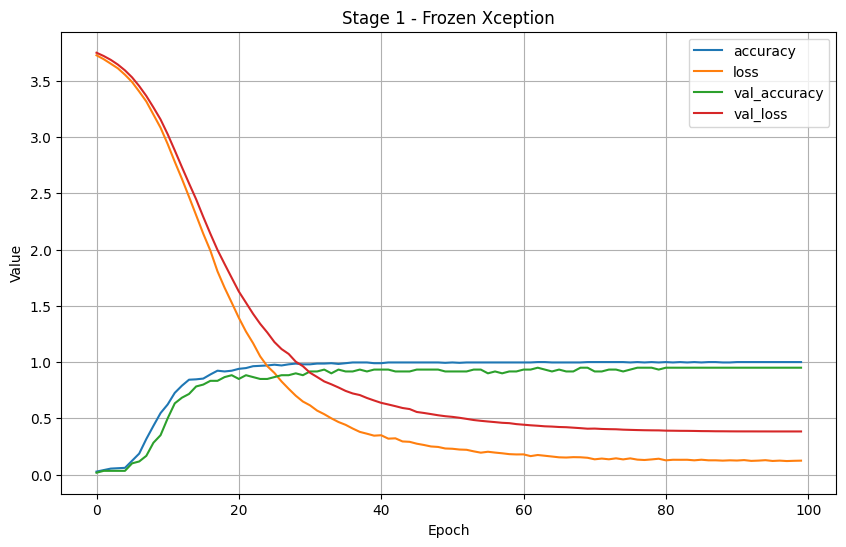

In [191]:

# ============================================================
# 22. PLOT STAGE 1
# ============================================================

pd.DataFrame(
    history_stage1.history
).plot(
    figsize=(10, 6)
)

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Value")

plt.title(
    "Stage 1 - Frozen Xception"
)

plt.show()



In [192]:

# ============================================================
# 23. FINE-TUNING
# ============================================================

print()
print("=" * 60)
print("STAGE 2: FINE-TUNING XCEPTION")
print("=" * 60)


# Unfreeze Xception
for layer in base_model.layers:
    layer.trainable = True


STAGE 2: FINE-TUNING XCEPTION


In [193]:

# ============================================================
# 24. FINE-TUNING LEARNING RATE
# ============================================================

# Much smaller LR for pretrained weights

EPOCHS_STAGE2 = 10000

total_steps_stage2 = (
    EPOCHS_STAGE2 * steps_per_epoch
)

one_cycle_stage2 = OneCycleLR(
    total_steps=total_steps_stage2,
    max_lr=1e-6,
    pct_start=0.3
)

In [194]:

# ============================================================
# 25. FINE-TUNING CALLBACKS
# ============================================================

early_stop_stage2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

checkpoint_stage2 = keras.callbacks.ModelCheckpoint(
    filepath="/content/my_logs/best_finetuned.keras",
    monitor="val_loss",
    save_best_only=True
)

run_logdir_stage2 = os.path.join(
    root_logdir,
    "stage2_" + time.strftime(
        "%Y_%m_%d-%H_%M_%S"
    )
)

tensorboard_stage2 = keras.callbacks.TensorBoard(
    run_logdir_stage2
)



In [195]:

# ============================================================
# 26. RECOMPILE AFTER UNFREEZING
# ============================================================

model.compile(

    loss="sparse_categorical_crossentropy",

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-6,
        clipnorm=1.0
    ),

    metrics=["accuracy"]
)



In [196]:

# ============================================================
# 27. FINE-TUNE
# ============================================================

history_stage2 = model.fit(

    train_set,

    epochs=EPOCHS_STAGE2,

    validation_data=valid_set,

    callbacks=[
        one_cycle_stage2,
        early_stop_stage2,
        checkpoint_stage2,
        tensorboard_stage2
    ]
)


Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.0467 - loss: 8.3857 - val_accuracy: 0.9167 - val_loss: 0.4404
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 249ms/step - accuracy: 0.0467 - loss: 8.7136 - val_accuracy: 0.8333 - val_loss: 0.8189
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 249ms/step - accuracy: 0.0533 - loss: 8.4618 - val_accuracy: 0.5833 - val_loss: 1.5660
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step - accuracy: 0.0600 - loss: 8.6027 - val_accuracy: 0.3333 - val_loss: 2.6698
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step - accuracy: 0.0500 - loss: 8.3895 - val_accuracy: 0.2167 - val_loss: 4.0833
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step - accuracy: 0.0500 - loss: 8.7420 - val_accuracy: 0.1667 - val_loss: 5.6299
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 261ms/step - accuracy: 0.0467 - loss: 8.6715 - val_accuracy: 0.1500 - val_loss: 7.0017
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step - accuracy: 0.0467 - loss: 8.

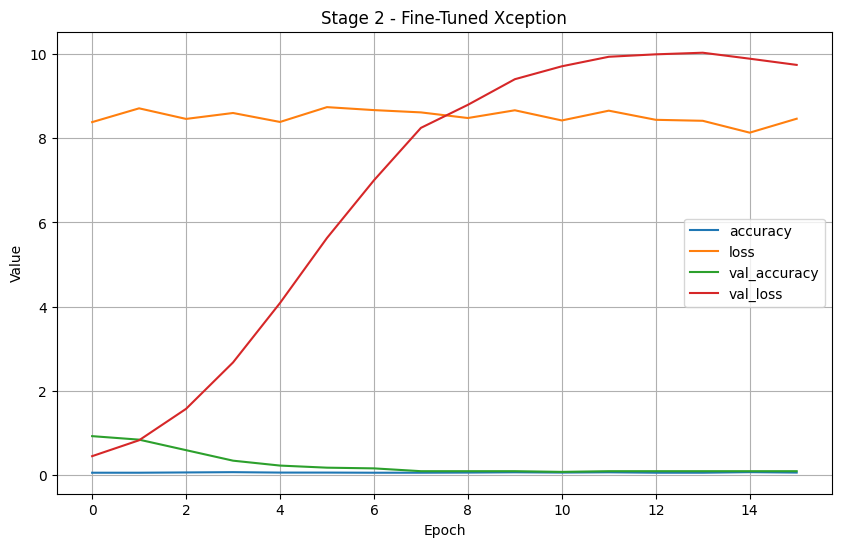

In [197]:

# ============================================================
# 28. PLOT FINE-TUNING
# ============================================================

pd.DataFrame(
    history_stage2.history
).plot(
    figsize=(10, 6)
)

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Value")

plt.title(
    "Stage 2 - Fine-Tuned Xception"
)

plt.show()


In [198]:

# ============================================================
# 29. FINAL TEST EVALUATION
# ============================================================

print()
print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(
    test_set
)

print(
    "Test loss:",
    test_loss
)

print(
    "Test accuracy:",
    test_accuracy
)


FINAL TEST RESULTS
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8750 - loss: 0.4112
Test loss: 0.4111889898777008
Test accuracy: 0.875


In [199]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 62,721,266 (239.26 MB)

 Trainable params: 20,888,912 (79.68 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 41,777,826 (159.37 MB)

In [203]:
from google.colab import files
files.download('/content/my_logs')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>